# 01 - Data Loading and Initial Inspection

## Project
AI Salary Structure & Remote Work Premium Analysis

## Objective of this notebook
This notebook loads the raw dataset and performs the first inspection:
- dataset shape
- column names
- data types
- missing values
- duplicates
- basic descriptive statistics

This is not the cleaning or modeling notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/raw/global_ai_jobs.csv"
df = pd.read_csv(file_path)

df.head()

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [3]:
df.shape

(90000, 35)

In [4]:
df.columns.tolist()

['id',
 'country',
 'job_role',
 'ai_specialization',
 'experience_level',
 'experience_years',
 'salary_usd',
 'bonus_usd',
 'education_required',
 'industry',
 'company_size',
 'interview_rounds',
 'year',
 'work_mode',
 'weekly_hours',
 'company_rating',
 'job_openings',
 'hiring_difficulty_score',
 'layoff_risk',
 'ai_adoption_score',
 'company_funding_billion',
 'economic_index',
 'ai_maturity_years',
 'offer_acceptance_rate',
 'tax_rate_percent',
 'vacation_days',
 'skill_demand_score',
 'automation_risk',
 'job_security_score',
 'career_growth_score',
 'work_life_balance_score',
 'promotion_speed',
 'salary_percentile',
 'cost_of_living_index',
 'employee_satisfaction']

In [5]:
df.info

<bound method DataFrame.info of           id    country                   job_role       ai_specialization  \
0          1        UAE  Machine Learning Engineer  Reinforcement Learning   
1          2        USA                AI Engineer                     LLM   
2          3     Brazil         Research Scientist               Analytics   
3          4      India       Software Engineer AI         Computer Vision   
4          5    Germany  Machine Learning Engineer         Computer Vision   
...      ...        ...                        ...                     ...   
89995  89996    Germany         Research Scientist             Forecasting   
89996  89997    Germany  Machine Learning Engineer                     NLP   
89997  89998  Singapore   Computer Vision Engineer         Computer Vision   
89998  89999    Germany                AI Engineer                   MLOps   
89999  90000        USA       Software Engineer AI               Analytics   

      experience_level  experie

In [6]:
df.isnull().sum().sort_values(ascending=False)

id                         0
skill_demand_score         0
company_funding_billion    0
economic_index             0
ai_maturity_years          0
offer_acceptance_rate      0
tax_rate_percent           0
vacation_days              0
automation_risk            0
layoff_risk                0
job_security_score         0
career_growth_score        0
work_life_balance_score    0
promotion_speed            0
salary_percentile          0
cost_of_living_index       0
ai_adoption_score          0
hiring_difficulty_score    0
country                    0
education_required         0
job_role                   0
ai_specialization          0
experience_level           0
experience_years           0
salary_usd                 0
bonus_usd                  0
industry                   0
job_openings               0
company_size               0
interview_rounds           0
year                       0
work_mode                  0
weekly_hours               0
company_rating             0
employee_satis

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["salary_usd"].describe()

count     90000.000000
mean      96546.249222
std       43935.479553
min       28000.000000
25%       64676.750000
50%       87544.000000
75%      123906.000000
max      300622.000000
Name: salary_usd, dtype: float64

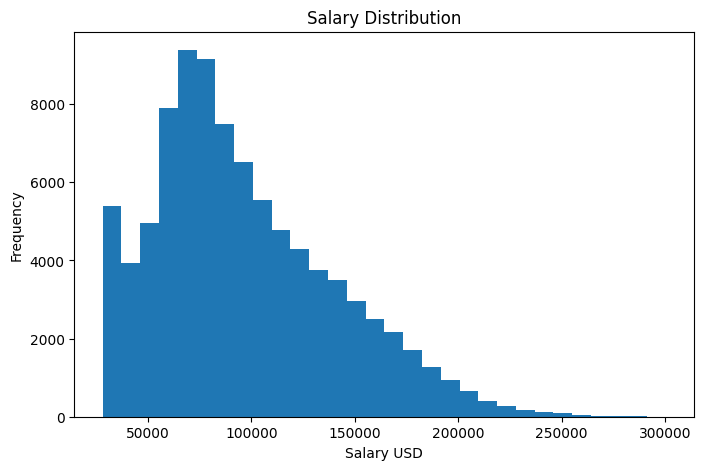

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["salary_usd"], bins=30)
plt.xlabel("Salary USD")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.show()

In [10]:
df["work_mode"].value_counts()

work_mode
Onsite    30233
Remote    30005
Hybrid    29762
Name: count, dtype: int64

In [11]:
df.groupby("work_mode")["salary_usd"].mean()

work_mode
Hybrid    96747.536153
Onsite    96450.876393
Remote    96442.689985
Name: salary_usd, dtype: float64

<Figure size 800x500 with 0 Axes>

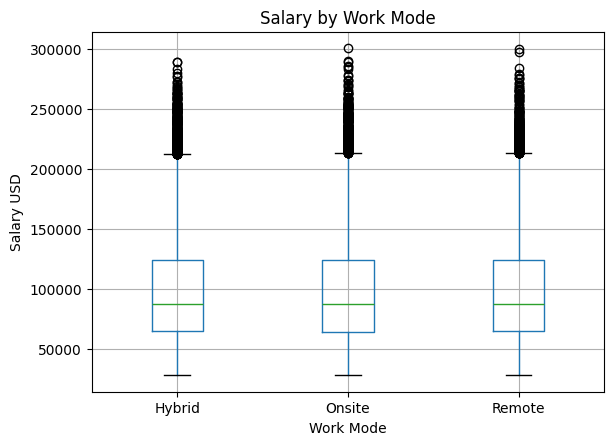

In [12]:
plt.figure(figsize=(8,5))

df.boxplot(column="salary_usd", by="work_mode")

plt.title("Salary by Work Mode")
plt.suptitle("")
plt.xlabel("Work Mode")
plt.ylabel("Salary USD")

plt.show()

In [13]:
from scipy import stats

remote = df[df["work_mode"] == "Remote"]["salary_usd"]
onsite = df[df["work_mode"] == "Onsite"]["salary_usd"]
hybrid = df[df["work_mode"] == "Hybrid"]["salary_usd"]

f_stat, p_value = stats.f_oneway(remote, onsite, hybrid)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.4669200966265753
p-value: 0.6269317009538833


In [14]:
df.groupby(["experience_level","work_mode"])["salary_usd"].mean()

experience_level  work_mode
Entry             Hybrid        61553.013810
                  Onsite        61330.296728
                  Remote        61101.715722
Lead              Hybrid       142009.320053
                  Onsite       142169.642885
                  Remote       142784.021640
Mid               Hybrid        77689.500000
                  Onsite        76967.115008
                  Remote        77586.010935
Senior            Hybrid       104965.395206
                  Onsite       104492.812829
                  Remote       104372.438527
Name: salary_usd, dtype: float64